In [1]:
import pandas as pd
import numpy as np
#import scvi
import scanpy as sc
import harmonypy as hm

## import the PBMC data from scvi package

In [12]:
#adata = scvi.data.pbmc_dataset()
adata = sc.read_h5ad("adata_pmbc_10k_original.h5ad")
adata

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts'
    uns: 'cell_types'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

# Original anndata space for batch effect

# For scBERT, scGPT and Geneformer, skip this step involving Harmony package
## Prepare for bacth correction using 'Harmony'

In [13]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# Ensure batch is categorical
adata.obs['batch'] = adata.obs['batch'].astype('category')

# Now run highly variable gene selection with batch awareness
#sc.pp.highly_variable_genes(adata, batch_key='batch')
#adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50)

In [14]:
# Step 2: Extract PCA and batch metadata
pca_data = adata.obsm['X_pca']
meta_data = pd.DataFrame({'batch': adata.obs['batch'].values})

# Step 3: Run Harmony
ho = hm.run_harmony(pca_data, meta_data, vars_use=['batch'])
# Step 4: Save Harmony output in adata.obsm
adata.obsm['X_pca_harmony'] = ho.Z_corr.T
adata

2025-05-01 09:27:47,253 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-05-01 09:27:50,356 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-05-01 09:27:50,424 - harmonypy - INFO - Iteration 1 of 10
2025-05-01 09:27:52,640 - harmonypy - INFO - Iteration 2 of 10
2025-05-01 09:27:54,655 - harmonypy - INFO - Iteration 3 of 10
2025-05-01 09:27:55,377 - harmonypy - INFO - Iteration 4 of 10
2025-05-01 09:27:56,101 - harmonypy - INFO - Converged after 4 iterations


AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'mean', 'std'
    uns: 'cell_types', 'log1p', 'pca'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc', 'X_pca', 'X_pca_harmony'
    varm: 'PCs'

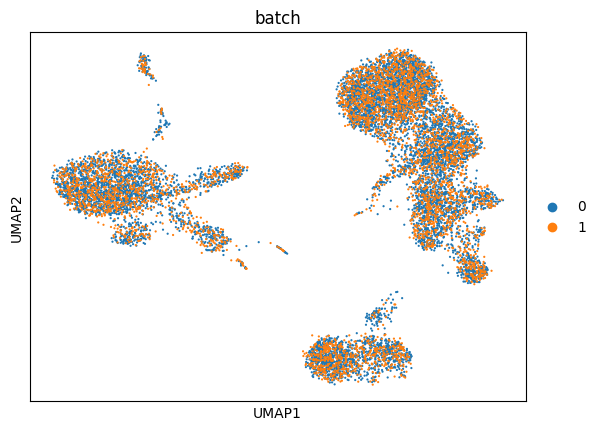

In [15]:
# Step 5: Use Harmony embedding for downstream analysis
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
sc.pl.umap(adata, color='batch')

# For all foundational models, run the following to get connectivity and silhouette scores

## Use "graph_connectivity" and "silhouette_batch" from scib.metrics to quantify the result of batch effect correction

In [22]:
from scib.metrics import graph_connectivity, silhouette_batch

In [23]:
score_gc = graph_connectivity(
    adata,
    label_key='str_labels',        # cell type or other biological labels
    # No use_rep param needed here
)

adata.obs['batch'] = adata.obs['batch'].astype('category')
adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')

# Run silhouette_batch correctly
asw_batch = silhouette_batch(
    adata,
    batch_key='batch',
    label_key='str_labels',            # <- this is what was missing
    embed='X_pca_harmony'
)



print(f"Harmony Itegrated Graph Connectivity: {score_gc:.3f}")
print(f"Harnomy ASW (Batch): {asw_batch:.3f}")

/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_cou

mean silhouette per group:                    silhouette_score
group                              
B cells                    0.985248
CD14+ Monocytes            0.973689
CD4 T cells                0.998214
CD8 T cells                0.997945
Dendritic Cells            0.954812
FCGR3A+ Monocytes          0.978968
Megakaryocytes             0.936871
NK cells                   0.990211
Other                      0.897176
Harmony Itegrated Graph Connectivity: 0.935
Harnomy ASW (Batch): 0.968


## Below we start using scFoundation embedded feature space for batch integration analysis

In [24]:
# Get the scFoundation embedding and add it to the adata
array= np.load("batch_data_01B-resolution_singlecell_cell_embedding_t4_resolution.npy")
print(len(array))
array

11990


array([[-1.2847406 ,  1.5508968 , -0.5695963 , ..., -0.07787142,
        -0.86071694, -1.8965319 ],
       [-1.0226264 ,  1.330935  , -0.23218316, ...,  0.59293985,
        -0.39656857, -2.0906236 ],
       [-1.2177157 ,  1.0461342 , -0.5865153 , ...,  0.04572099,
        -1.4267184 , -1.3192849 ],
       ...,
       [-0.6038156 ,  0.69455385,  0.48275334, ...,  0.22034357,
        -1.6934824 , -1.8897696 ],
       [-0.6012602 ,  0.31873605, -0.47541043, ...,  0.6056661 ,
        -1.2794371 , -1.09494   ],
       [-1.0325282 ,  1.0946673 , -0.6787208 , ..., -0.09076344,
        -1.86244   , -1.5041376 ]], shape=(11990, 3072), dtype=float32)

## Add embeddings from scFoundation model

In [25]:
# convert scF embedded data to anndata
adata.obsm["scFoundation"] = array
#adata.obs["cell_type"]= adata.uns["cell_types"]
adata

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'mean', 'std'
    uns: 'cell_types', 'log1p', 'pca', 'neighbors', 'umap', 'batch_colors'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc', 'X_pca', 'X_pca_harmony', 'X_umap', 'scFoundation'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [26]:
embedding =adata.obsm['scFoundation']


## Plot batch umap on scFoundation embedding prior to Harmony batch correction

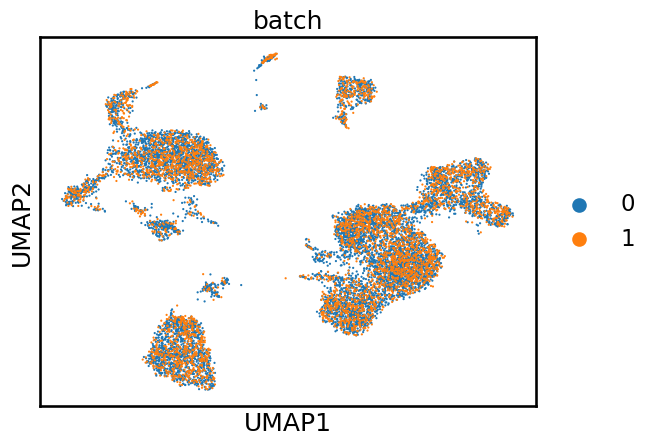

In [27]:
sc.pp.neighbors(adata, use_rep='scFoundation')
sc.tl.umap(adata)

#Plot UMAP colored by batch
sc.pl.umap(adata, color='batch', save="scFoundation_generated_batch_UMAP.svg")
#sc.pl.umap(
#    adata,
#    color=['batch', 'cell_type'],
#    wspace=0.4,           # space between plots
#    legend_loc='right margin',  # or 'on data' for direct labels
#    ncols=2
#)

In [29]:
adata

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'mean', 'std'
    uns: 'cell_types', 'log1p', 'pca', 'neighbors', 'umap', 'batch_colors'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc', 'X_pca', 'X_pca_harmony', 'X_umap', 'scFoundation'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [30]:
#from scib.metrics import graph_connectivity, silhouette_batch
adata.obs['labels'] = adata.obs['labels'].astype('category')

adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')
gc = graph_connectivity(adata, label_key='str_labels')


# Run silhouette_batch correctly
asw_batch = silhouette_batch(
    adata,
    batch_key='batch',
    label_key='str_labels', 
    embed='scFoundation'
)

print(f"scFoundation (no Harmony) Graph Connectivity: {gc:.3f}")
print(f"scFoundation (no Harmony) ASW(b): {asw_batch:.3f}")

/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_cou

mean silhouette per group:                    silhouette_score
group                              
B cells                    0.987139
CD14+ Monocytes            0.974197
CD4 T cells                0.992390
CD8 T cells                0.989806
Dendritic Cells            0.951885
FCGR3A+ Monocytes          0.983514
Megakaryocytes             0.957044
NK cells                   0.989714
Other                      0.913207
scFoundation (no Harmony) Graph Connectivity: 0.932
scFoundation (no Harmony) ASW(b): 0.971


# Run Harmony for batch integration on the scFoundation embedded space

In [36]:
# Make sure your batch column is categorical
adata.obs['batch'] = adata.obs['batch'].astype('category')

# Step 1: Extract the scFoundation embedding
embedding = adata.obsm['scFoundation']


# Step 2: Prepare metadata as DataFrame
meta_data = pd.DataFrame({'batch': adata.obs['batch'].values})

# Step 3: Run Harmony
ho = hm.run_harmony(embedding, meta_data, vars_use=['batch'])
"""
# Step 4: Save the batch-corrected embedding back to adata
adata.obsm['scFoundation_harmony'] = ho.Z_corr.T
"""

2025-04-18 10:38:55,564 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-18 10:40:54,123 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-18 10:40:54,318 - harmonypy - INFO - Iteration 1 of 10
2025-04-18 10:41:41,993 - harmonypy - INFO - Iteration 2 of 10
2025-04-18 10:42:29,758 - harmonypy - INFO - Iteration 3 of 10
2025-04-18 10:43:10,423 - harmonypy - INFO - Iteration 4 of 10
2025-04-18 10:43:47,650 - harmonypy - INFO - Converged after 4 iterations


"\n# Step 4: Save the batch-corrected embedding back to adata\nadata.obsm['scFoundation_harmony'] = ho.Z_corr.T\n"

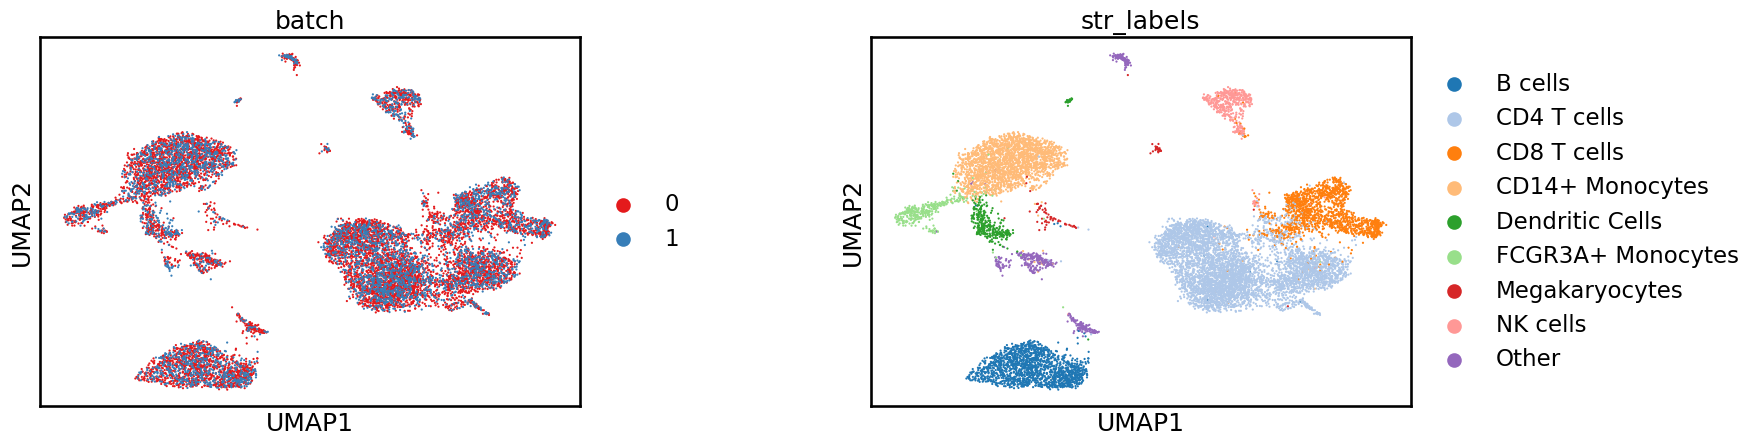

In [37]:
adata.obsm['scFoundation_harmony'] = ho.Z_corr.T

# Step 5: Recalculate neighbors and UMAP using the corrected embedding
sc.pp.neighbors(adata, use_rep='scFoundation_harmony')
sc.tl.umap(adata)
#sc.pl.umap(adata, color='batch', title='scFoundation Harmony-corrected UMAP')
sc.pl.umap(
    adata,
    color=['batch', 'str_labels'],
    wspace=0.4,           # space between plots
    legend_loc='right margin',  # or 'on data' for direct labels
    ncols=2
)

In [38]:
#from scib.metrics import graph_connectivity, silhouette_batch
adata.obs['labels'] = adata.obs['labels'].astype('category')

adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')
gc = graph_connectivity(adata, label_key='str_labels')


# Run silhouette_batch correctly
asw_batch = silhouette_batch(
    adata,
    batch_key='batch',
    label_key='str_labels', 
    embed='scFoundation_harmony'
)

print(f"Graph Connectivity: {gc:.3f}")
print(f"ASW(b): {asw_batch:.3f}")

/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_cou

mean silhouette per group:                    silhouette_score
group                              
B cells                    0.989032
CD14+ Monocytes            0.976718
CD4 T cells                0.996676
CD8 T cells                0.994847
Dendritic Cells            0.955011
FCGR3A+ Monocytes          0.983821
Megakaryocytes             0.955508
NK cells                   0.990702
Other                      0.918754
Graph Connectivity: 0.932
ASW(b): 0.973
